# Problem C: Surrogate Modeling for Steady-State Heat Conduction in Heterogeneous Materials

Consider the steady-state heat conduction problem in a heterogeneous solid material occupying the unit square domain $\Omega = [0,1]^2$:

$$
\begin{split}
-\nabla\cdot(a(x,y)\nabla u) &= f,\quad (x,y)\in\Omega=[0,1]^2 \\
u &= 0,\quad (x,y)\in\partial\Omega
\end{split} \tag{2}
$$

where $u(x,y)$ denotes the temperature field, $a(x,y) > 0$ denotes the spatially varying thermal conductivity of the material, and the uniform heat source is given by $f = 10$. The zero Dirichlet boundary condition models a configuration in which the boundary of the domain is kept at a fixed reference temperature.

In computational materials science, evaluating the thermal response of a large number of candidate microstructures is a central bottleneck in material screening and design workflows. Although high-fidelity Finite Element Method (FEM) solvers can produce accurate solutions, they are computationally expensive when applied repeatedly to thousands of different conductivity fields $a(x,y)$.

## Task: Learning the Solution Operator $a(x,y) \mapsto u(x,y)$

The goal of this task is to make a fast prediction of the temperature field $u(x,y)$ given $a(x,y)$. To this end, a dataset of input-output pairs $\{a^{(j)}, u^{(j)}\}$ has been pre-computed using a high-precision FEM solver. The conductivity fields $a^{(j)}$ are sampled from a distribution $\mathcal{A}$ over spatially heterogeneous functions, representative of realistic microstructural variability in composite materials. Once trained, the model should accurately predict the temperature field for new, unseen conductivity samples drawn from the same distribution $\mathcal{A}$, at a fraction of the cost of a full FEM solve.

### Goals

- Please select a suitable deep learning method for this task and justify your choice.
- Report your implementation setup, including network architecture, activation function, optimizer (with learning rate), number of epochs, batch size, loss formulation, and any additional techniques used for improvement.
- Compute the $L^2$ relative error on the **test dataset** at each training epoch and plot the `Error vs. Epoch` curve (reporting the final error). The $L^2$ relative error between predictions $\{u^{(j)}_{\text{pred}}\}_{j=1}^{N}$ and ground truth $\{u^{(j)}_{\text{true}}\}_{j=1}^{N}$ is defined as:

$$
\text{error} = \frac{1}{N}\sum_{j=1}^{N}\sqrt{\frac{\sum_i\left|u^{(j)}_{\text{pred}}(x_i)-u^{(j)}_{\text{true}}(x_i)\right|^2}{\sum_i\left|u^{(j)}_{\text{true}}(x_i)\right|^2}}
$$

where $j$ indexes the sample and $i$ indexes the spatial grid point.

- For the **first test instance**, use `matplotlib` to plot the following in separate figures:
  1. The input conductivity field $a(x,y)$
  2. The predicted temperature field $u_{\text{pred}}(x,y)$
  3. The ground truth temperature field $u_{\text{true}}(x,y)$
  4. The pointwise absolute error $|u_{\text{pred}} - u_{\text{true}}|$

### Dataset

The training and test data are provided in `ProblemC_dataset.h5`:

| Key | Shape | Description |
|---|---|---|
| `a_train` | (1000, 128, 128) | Training conductivity fields sampled from $\mathcal{A}$ |
| `u_train` | (1000, 128, 128) | Corresponding FEM-computed temperature fields (training) |
| `a_test` | (200, 128, 128) | Test conductivity fields (for error evaluation only, **do not use for training**) |
| `u_test` | (200, 128, 128) | Corresponding FEM-computed temperature fields (test reference, **do not use for training**) |
| `X` | (128, 128) | $x$-coordinates of the $128\times 128$ regular spatial grid |
| `Y` | (128, 128) | $y$-coordinates of the $128\times 128$ regular spatial grid |

> 📥 Dataset download: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

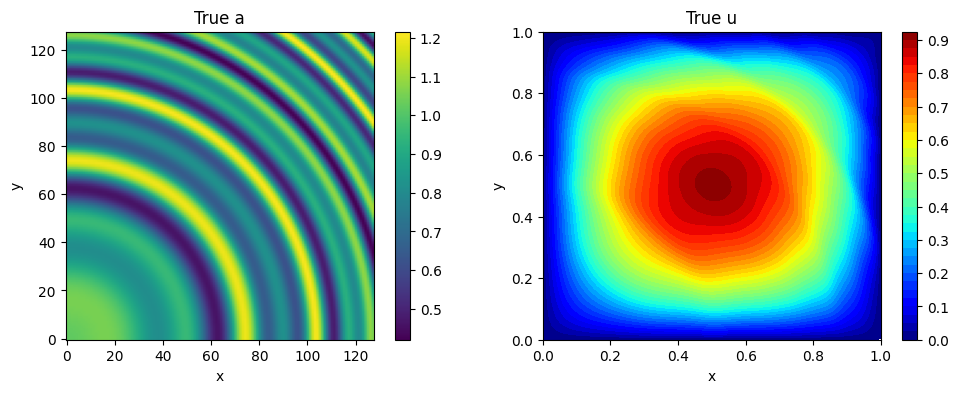

In [23]:
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import torch.nn as nn
from tqdm import trange
from torch.utils.data import Dataset, DataLoader
import time
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
torch.manual_seed(1234)


#datafetching
with h5py.File('ProblemC_dataset.h5', 'r') as data:
    a_train = torch.tensor(np.array(data["a_train"]), dtype=dtype)
    u_train = torch.tensor(np.array(data["u_train"]), dtype=dtype)
    a_test = torch.tensor(np.array(data["a_test"]), dtype=dtype)
    u_test = torch.tensor(np.array(data["u_test"]), dtype=dtype)
    # The coordinates
    X = torch.tensor(np.array(data['X']), dtype=dtype)
    Y = torch.tensor(np.array(data['Y']), dtype=dtype)

grid = torch.stack([X,Y], dim=-1)
grid_train = grid.unsqueeze(0).repeat(a_train.shape[0],1,1,1)
grid_test = grid.unsqueeze(0).repeat(a_test.shape[0],1,1,1)
ax_train = torch.cat([a_train.unsqueeze(-1), grid_train], dim=-1)
ax_test = torch.cat([a_test.unsqueeze(-1), grid_test], dim=-1)
u_train = u_train.unsqueeze(-1)
u_test = u_test.unsqueeze(-1)

####### Visualize the training data
a_show, u_show = a_train[1], u_train[1]
#
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
#
cntr0 = axs.flat[:][0].imshow(a_show, origin='lower')
fig.colorbar(cntr0, ax=axs.flat[:][0])
axs.flat[:][0].set_title('True a')
axs.flat[:][0].set_xlabel('x')
axs.flat[:][0].set_ylabel('y')
#
u_show=np.squeeze(u_show)
cntr1 = axs.flat[:][1].contourf(X, Y, u_show, levels=40, cmap='jet')
fig.colorbar(cntr1, ax=axs.flat[:][1])
axs.flat[:][1].set_title('True u')
axs.flat[:][1].set_xlabel('x')
axs.flat[:][1].set_ylabel('y')
#
plt.show()

In [24]:
class UnitGaussianNormalizer():
    def __init__(self, ax, eps=1e-8):
        super(UnitGaussianNormalizer, self).__init__()
        '''Apply normaliztion to the first dimension of last axis of ax'''
        self.mean = torch.mean(ax[...,0:1], 0)
        self.std = torch.std(ax[...,0:1], 0)
        self.eps = eps

    def encode(self, ax):
        d = ax.shape[-1] - 1
        ax_list = torch.split(ax, split_size_or_sections=[1, d], dim=-1)
        ax = torch.cat([(ax_list[0]-self.mean) / (self.std + self.eps), ax_list[1]], dim=-1)
        return ax

    def decode(self, ax):
        d = ax.shape[-1] - 1
        ax_list = torch.split(ax, split_size_or_sections=[1, d], dim=-1)
        ax = torch.cat([ax_list[0] * (self.std + self.eps) + self.mean, ax_list[1]], dim=-1)
        return ax

normalizer_ax = UnitGaussianNormalizer(ax_train.to(device))
normalizer_u = UnitGaussianNormalizer(u_train.to(device))

#fno arch
class SpectralConv2d(nn.Module):
    def __init__(self, in_size, out_size, modes1, modes2, dtype):
        super(SpectralConv2d, self).__init__()
        '''2D Fourier layer: FFT -> linear transform -> Inverse FFT'''
        self.in_size = in_size
        self.out_size = out_size
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1./(in_size * out_size)

        if (dtype is None) or (dtype==torch.float32):
            ctype = torch.complex64
        elif (dtype==torch.float64):
            ctype = torch.complex128
        else:
            raise TypeError(f'No such data type.')

        self.weight1 = nn.Parameter(self.scale * torch.rand(in_size, out_size, modes1, modes2, dtype=ctype))
        self.weight2 = nn.Parameter(self.scale * torch.rand(in_size, out_size, modes1, modes2, dtype=ctype))

    def compl_mul_2d(self, input, weights):
        '''Complex multiplication'''
        return torch.einsum('bixy,ioxy->boxy', input, weights)

    def forward(self, x):
        batch_size = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(batch_size, self.out_size, x.size(-2), x.size(-1)//2+1, device=x.device, dtype=torch.cfloat)

        out_ft[:, :, :self.modes1, :self.modes2] \
            = self.compl_mul_2d(x_ft[:, :, :self.modes1, :self.modes2], self.weight1)
        out_ft[:, :, -self.modes1:, :self.modes2] \
            = self.compl_mul_2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weight2)

        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x

class FNO2d(nn.Module):
    def __init__(self, in_size:int, out_size:int, modes1:int, modes2:int, hidden_list:list[int], dtype=None):
        super(FNO2d, self).__init__()
        self.hidden_list = hidden_list
        self.activation = nn.ReLU()
        self.fc_in = nn.Linear(in_size, hidden_list[0], dtype=dtype)

        conv_net, w_net = [], []
        self.hidden_in = hidden_list[0]
        for hidden in hidden_list[1:]:
            conv_net.append(SpectralConv2d(self.hidden_in, hidden, modes1, modes2, dtype))
            w_net.append(nn.Conv1d(self.hidden_in, hidden, 1, dtype=dtype))
            self.hidden_in =  hidden

        self.spectral_conv = nn.Sequential(*conv_net)
        self.weight_conv = nn.Sequential(*w_net)

        self.fc_out0 = nn.Linear(self.hidden_in, 128, dtype=dtype)
        self.fc_out1 = nn.Linear(128, out_size, dtype=dtype)

    def forward(self, ax):
        batch_size = ax.shape[0]
        mx_size, my_size = ax.shape[1], ax.shape[2]

        ax = self.fc_in(ax)
        ax = ax.permute(0, 3, 1, 2)

        hidden_last = self.hidden_list[0]
        for conv, weight, hidden_size in zip(self.spectral_conv, self.weight_conv, self.hidden_list[1:]):
            ax1 = conv(ax)
            ax2 = weight(ax.view(batch_size, hidden_last, -1)).view(batch_size, hidden_size, mx_size, my_size)
            ax = self.activation(ax1+ax2)
            hidden_last = hidden_size

        ax = ax.permute(0, 2, 3, 1)
        ax = self.fc_out0(ax)
        ax = self.activation(ax)
        return self.fc_out1(ax)

#lossfunction
class LossClass(object):
    def __init__(self, u_model):
        self.device = device
        self.u_model = u_model

    def loss_data(self, ax_batch, u_batch):
        '''loss term'''
        batch_size = u_batch.shape[0]
        ax, u = ax_batch.to(self.device), u_batch.to(self.device)
        ax_norm = normalizer_ax.encode(ax)
        u_pred_norm = self.u_model(ax_norm)
        u_pred = normalizer_u.decode(u_pred_norm)

        loss = torch.norm(u.reshape(batch_size, -1)-u_pred.reshape(batch_size, -1), 2, 1)
        loss = torch.mean(loss)
        return loss

    def get_error(self, ax, u):
        '''L2 relative error'''
        batch_size = u.shape[0]
        ax, u = ax.to(self.device), u.to(self.device)
        ax_norm = normalizer_ax.encode(ax)
        u_pred_norm = self.u_model(ax_norm)
        u_pred = normalizer_u.decode(u_pred_norm)

        error = torch.norm(u.reshape(batch_size,-1)-u_pred.reshape(batch_size,-1), 2, 1) / torch.norm(u.reshape(batch_size,-1), 2, 1)
        return torch.mean(error)

def L2_error(u, u_pred):
    ndata = u.shape[0]
    l2 = torch.norm(u.reshape(ndata,-1)-u_pred.reshape(ndata,-1), 2, 1) / torch.norm(u.reshape(ndata, -1), 2, 1)
    return l2

#modeltraining
class MyDataset(Dataset):
    def __init__(self, ax:torch.tensor, u:torch.tensor):
        self.ax = ax
        self.u = u

    def __getitem__(self, index):
        return self.ax[index], self.u[index]

    def __len__(self):
        return self.ax.shape[0]

mode1, mode2 = 12, 12
hidden_list = [32, 32, 32, 32]
model_u = FNO2d(ax_train.shape[-1], u_train.shape[-1], mode1, mode2, hidden_list, dtype).to(device)

train_loader = DataLoader(MyDataset(ax_train, u_train), batch_size=20, shuffle=True)

epochs = 100
lr = 1e-4
optimizer = torch.optim.Adam(params=model_u.parameters(), lr=lr, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.5)

loss_list, error_list = [], []
t0 = time.time()

for epoch in trange(epochs):
    model_u.train()
    loss = 0.
    for ax_batch, u_batch in train_loader:
        lossClass = LossClass(model_u)
        loss_train = lossClass.loss_data(ax_batch, u_batch)

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        loss += loss_train.item()

    scheduler.step()

    model_u.eval()
    with torch.no_grad():
        error = lossClass.get_error(ax_test, u_test)
        error_list.append(error.item())

    loss = loss / len(train_loader)
    loss_list.append(loss)

    if (epoch+1) % 10 == 0:
        print(f'Epoch: {epoch+1}, Loss: {loss:.4f} | error_test: {error_list[-1]:.4f}')

print('The consuming time is:', time.time()-t0)
print(f"\nFinal L2 Relative Error on Test Set: {error_list[-1]:.4f}")

 10%|█         | 10/100 [00:33<05:04,  3.39s/it]

Epoch: 10, Loss: 1.0594 | error_test: 0.0146


 20%|██        | 20/100 [01:07<04:30,  3.38s/it]

Epoch: 20, Loss: 0.5493 | error_test: 0.0103


 30%|███       | 30/100 [01:41<03:54,  3.34s/it]

...

Epoch: 80, Loss: 0.3043 | error_test: 0.0086


 90%|█████████ | 90/100 [05:01<00:33,  3.35s/it]

Epoch: 90, Loss: 0.3002 | error_test: 0.0084


100%|██████████| 100/100 [05:35<00:00,  3.35s/it]

Epoch: 100, Loss: 0.2950 | error_test: 0.0085
The consuming time is: 335.43921518325806

Final L2 Relative Error on Test Set: 0.0085


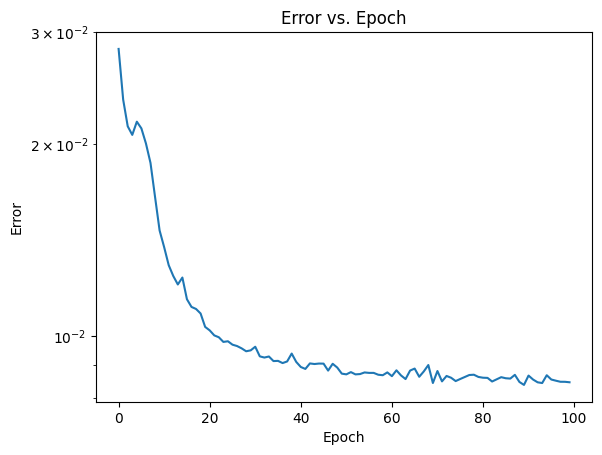

In [27]:
#errorvsepoch
plt.figure()
plt.semilogy(error_list)
plt.title('Error vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.show()

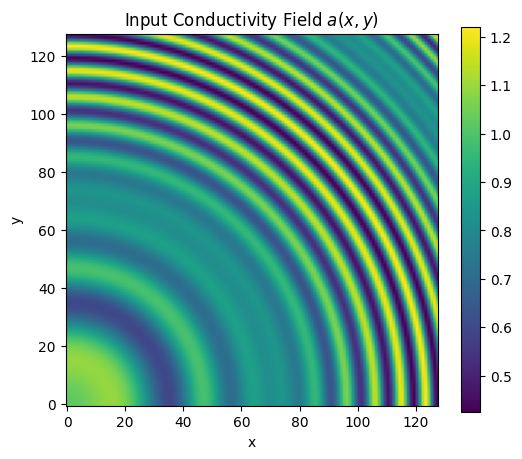

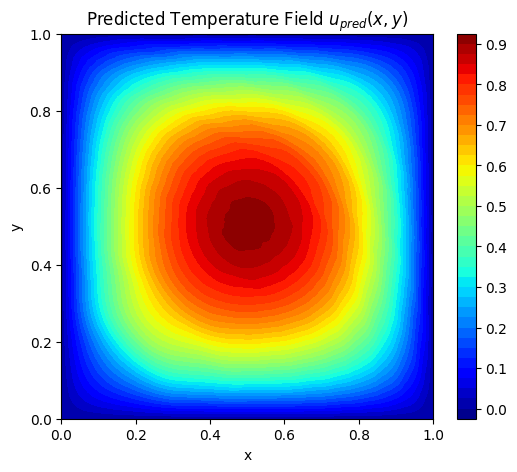

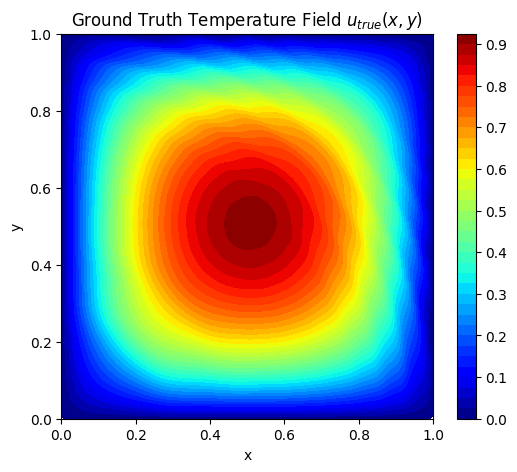

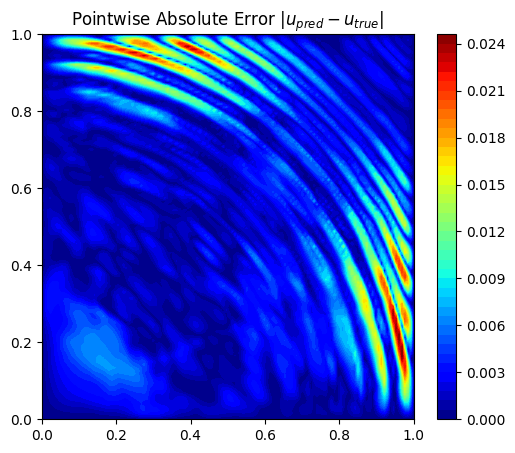

In [28]:
#lastpart
model_u.eval()
with torch.no_grad():
    ax_test_norm = normalizer_ax.encode(ax_test.to(device))
    u_test_pred_norm = model_u(ax_test_norm)
    u_test_pred = normalizer_u.decode(u_test_pred_norm).detach().cpu()

u_true = u_test[0].squeeze().numpy()
u_pred = u_test_pred[0].squeeze().numpy()
a_true = a_test[0].numpy()
abs_err = np.abs(u_pred - u_true)
X_np = X.numpy()
Y_np = Y.numpy()

#a(x,y)
plt.figure(figsize=(6, 5))
cntr1 = plt.imshow(a_true, origin='lower')
plt.colorbar(cntr1)
plt.title('Input Conductivity Field $a(x,y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

#upred
plt.figure(figsize=(6, 5))
cntr2 = plt.contourf(X_np, Y_np, u_pred, levels=40, cmap='jet')
plt.colorbar(cntr2)
plt.title('Predicted Temperature Field $u_{pred}(x,y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

#utrue
plt.figure(figsize=(6, 5))
cntr3 = plt.contourf(X_np, Y_np, u_true, levels=40, cmap='jet')
plt.colorbar(cntr3)
plt.title('Ground Truth Temperature Field $u_{true}(x,y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

#pointwise
plt.figure(figsize=(6, 5))
cntr4 = plt.contourf(X_np, Y_np, abs_err, levels=40, cmap='jet')
plt.colorbar(cntr4)
plt.title('Pointwise Absolute Error $|u_{pred} - u_{true}|$')
plt.show()